<a href="https://colab.research.google.com/github/asetya/BigData/blob/master/heuristic_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Heuristic
**FUNGSI Astar**

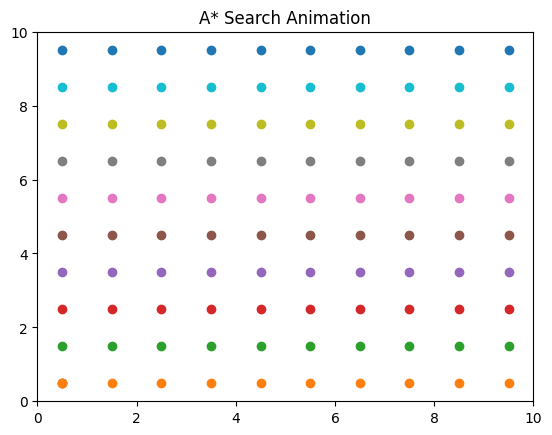

In [10]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import heapq

grid_size = 10
start = (0, 0)
goal = (9, 9)

def heuristic(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def neighbors(node):
    x, y = node
    dirs = [(1,0),(-1,0),(0,1),(0,-1)]
    result = []
    for dx, dy in dirs:
        nx, ny = x+dx, y+dy
        if 0 <= nx < grid_size and 0 <= ny < grid_size:
            result.append((nx, ny))
    return result

def a_star():
    open_list = []
    heapq.heappush(open_list, (0, start))

    came_from = {}
    g = {start: 0}
    visited = []

    while open_list:
        _, current = heapq.heappop(open_list)
        visited.append(current)

        if current == goal:
            break

        for n in neighbors(current):
            temp = g[current] + 1
            if n not in g or temp < g[n]:
                g[n] = temp
                f = temp + heuristic(n, goal)
                heapq.heappush(open_list, (f, n))
                came_from[n] = current

    return visited

visited_nodes = a_star()

fig, ax = plt.subplots()
ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.set_title("A* Search Animation")

def update(frame):
    node = visited_nodes[frame]
    ax.scatter(node[0]+0.5, node[1]+0.5)
    return ax,

ani = FuncAnimation(fig, update, frames=len(visited_nodes), interval=300)

HTML(ani.to_jshtml())

# Meta Heuristic

# Genetic Algorithms

# Particle Swarm Optimization

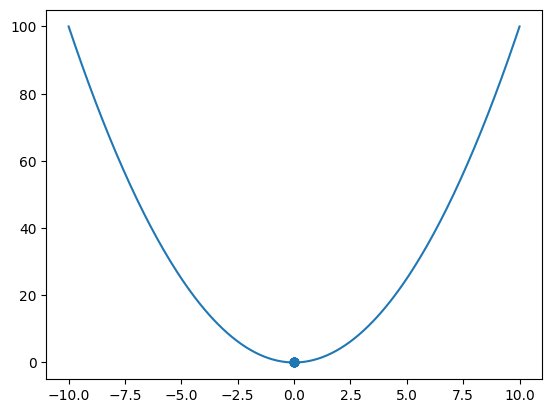

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import random

NUM_PARTICLES = 15
ITERATIONS = 50

w, c1, c2 = 0.5, 1.5, 1.5

def fitness(x):
    return x**2

particles = np.random.uniform(-10, 10, NUM_PARTICLES)
velocities = np.random.uniform(-1, 1, NUM_PARTICLES)

p_best = particles.copy()
g_best = particles[np.argmin(fitness(particles))]

fig, ax = plt.subplots()
x = np.linspace(-10, 10, 200)
ax.plot(x, x**2)
scat = ax.scatter(particles, fitness(particles))

def update(frame):
    global particles, velocities, p_best, g_best

    for i in range(NUM_PARTICLES):
        r1, r2 = random.random(), random.random()

        velocities[i] = (
            w * velocities[i]
            + c1 * r1 * (p_best[i] - particles[i])
            + c2 * r2 * (g_best - particles[i])
        )

        particles[i] += velocities[i]

        if fitness(particles[i]) < fitness(p_best[i]):
            p_best[i] = particles[i]

    g_best = p_best[np.argmin(fitness(p_best))]
    scat.set_offsets(np.c_[particles, fitness(particles)])
    return scat,

ani = FuncAnimation(fig, update, frames=ITERATIONS, interval=200)
HTML(ani.to_jshtml())